# Dự đoán giá nhà bằng ML đơn giản

Code này làm 5 việc:
1. Tạo dataset giá nhà giả lập
2. Chia train/test
3. Chuẩn hóa dữ liệu
4. Train Linear Regression
5. So sánh mô hình **có PCA** và **không PCA**

### Các python packages cân thiết:
- **numpy**: là thư viện nền tảng để xử lý số học, giúp tạo và thao tác với các mảng dữ liệu nhiều chiều (ma trận) cực nhanh. Dùng tạo dữ liệu giả lập và tính toán toán học trong bài này.
- **scikit-learn**: là thư viện phổ biến nhất cho ML, cung cấp sẵn các thuật toán (Linear Regression, ...), công cụ chia dữ liệu, chuẩn hóa và đánh giá model.

In [ ]:
!pip install numpy scikit-learn

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# 1. TẠO DATASET GIẢ LẬP
# =========================================================
def create_housing_data(n_samples=200, random_state=42):
  """
  Tạo dataset giả lập cho bài toán dự đoán giá nhà.

  Features:
  - size_m2: diện tích nhà (m2)
  - bedrooms: số phòng ngủ
  - distance_km: khoảng cách đến trung tâm (km)
  - age_years: tuổi căn nhà
  - size_ft2: diện tích nhà theo ft2 (feature dư thừa với size_m2)

  Target:
  - price: giá nhà
  """

  rng = np.random.default_rng(random_state)

  size_m2 = rng.uniform(30, 200, n_samples)       # 30 -> 200 m2
  bedrooms = rng.integers(1, 6, n_samples)        # 1 -> 5 phòng
  distance_km = rng.uniform(1, 20, n_samples)     # 1 -> 20 km
  age_years = rng.integers(0, 30, n_samples)      # 0 -> 30 năm

  # Feature dư thừa gần phụ thuộc tuyến tính với size_m2
  size_ft2 = size_m2 * 10.7639 + rng.normal(0, 5, n_samples)

  # Công thức giá giả lập
  # giá = 3000 * diện tích + 15000 * số phòng - 5000 * khoảng cách - 2000 * tuổi + nhiễu
  noise = rng.normal(0, 20000, n_samples)
  price = (
      3000 * size_m2 +
      15000 * bedrooms -
      5000 * distance_km -
      2000 * age_years +
      noise
  )

  X = np.column_stack([size_m2, bedrooms, distance_km, age_years, size_ft2])
  y = price

  feature_names = ["size_m2", "bedrooms", "distance_km", "age_years", "size_ft2"]
  return X, y, feature_names

# =========================================================
# 2. HÀM HIỂN THỊ THÔNG TIN DATASET
# =========================================================
def describe_dataset(X, y, feature_names):
  print("=" * 60)
  print("DATASET OVERVIEW")
  print("=" * 60)
  print(f"So mau: {X.shape[0]}")
  print(f"So feature: {X.shape[1]}")
  print("Danh sach feature:", feature_names)
  print()

  print("5 dong dau cua X:")
  print(X[:5])
  print()

  print("5 gia tri dau cua y:")
  print(y[:5])
  print()


In [ ]:
X, y, feature_names = create_housing_data()
describe_dataset(X, y, feature_names)

DATASET OVERVIEW
So mau: 200
So feature: 5
Danh sach feature: ['size_m2', 'bedrooms', 'distance_km', 'age_years', 'size_ft2']

5 dong dau cua X:
[[ 161.57252825    5.           15.80093074   24.         1745.3902868 ]
 [ 104.60933476    4.            3.55649196   22.         1124.74183173]
 [ 175.96164638    2.           11.18529268   16.         1895.85083721]
 [ 148.55256494    5.           10.77023453   26.         1586.95534393]
 [  46.01014914    3.           17.29387074    3.          489.46690604]]

5 gia tri dau cua y:
[440652.7571686  313253.26304279 443905.43340309 413782.57991585
  88966.50245392]



In [ ]:
# =========================================================
# 3. TRAIN VÀ ĐÁNH GIÁ MODEL KHÔNG PCA
#  Dùng toàn bộ đặc trưng gốc để train nhưng vì có 1 hoặc nhiều đặc trưng tương đồng (multicollinearity)
#  nên dẫn tới model có thể bị nhiễu, các hệ số (coeefficients) trở nên thiếu ổn định vì có nhiều cột dữ
#  liệu tranh giành tầm ảnh hưởng
#  Kết luận: Giữ nguyên ý nghĩa vật lý của từng cột nhưng dễ bị lỗi nếu dữ liệu trùng lặp nhiều
# =========================================================
def train_linear_regression_without_pca(X_train, X_test, y_train, y_test, feature_names):
  print("=" * 60)
  print("MODEL 1: LINEAR REGRESSION KHONG PCA")
  print("=" * 60)

  # Chuẩn hóa dữ liệu
  # Vì các features có các đơn vị và giá trị hoàn toàn khác nhau, nên việc chuẩn hóa dữ liệu
  # đưa giá trị trung bình (mean) về 0 và độ lệch chuẩn (std) về 1 để tạo sự công bằng
  # khi đem giá trị ra train, và đồng thời tạo điều kiện cho các thuật toán sau này
  # chạy trên tập dữ liệu chuẩn hóa nhan hơn và chính xác hơn
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # Train model
  model = LinearRegression()
  model.fit(X_train_scaled, y_train)

  # Predict
  y_pred = model.predict(X_test_scaled)

  # Metrics
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print("He so model sau khi scale:")
  for name, coef in zip(feature_names, model.coef_):
    print(f" {name:12s}: {coef:10.2f}")

  print(f"\nIntercept: {model.intercept_:.2f}")
  print(f"MSE  : {mse:.2f}")
  print(f"RMSE : {rmse:.2f}")
  print(f"R2   : {r2:.4f}")
  print()

  return {
      "scaler": scaler,
      "model": model,
      "y_pred": y_pred,
      "mse": mse,
      "rmse": rmse,
      "r2": r2,
  }

# =========================================================
# 4. TRAIN VÀ ĐÁNH GIÁ MODEL CÓ PCA
#  PCA sẽ nén 5 đặc trưng gốc thành 3 principal components (PC) mới nhằm
#   1. Loại bỏ dư thừa: PCA nhận ra size_m2 và size_ft biến thiên cùng nhau nên gộp chúng lại thành 1 PC duy nhất, loại bỏ trùng lặp
#   2. Giảm nhiễu: Tập trung vào những hướng có biến động dữ liệu lớn nhất và bỏ qua những biến động nhỏ (nhiễu)
#   3. Đơn giản hóa: Bạn chỉ cần dùng 3 biến mới và vẫn giữ được hơn 80% thông tin ban đầu
#  Kết luận: Làm dữ liệu "sạch" và gọn hơn, giúp mô hình ổn định hơn khi gặp dữ liệu có độ tương quan cao.
# =========================================================
def train_linear_regression_with_pca(X_train, X_test, y_train, y_test, n_components=3):
  print("=" * 60)
  print(f"MODEL 2: LINEAR REGRESSION WITH PCA (n_components={n_components})")
  print("=" * 60)

  # Scale trước khi PCA
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # PCA
  pca = PCA(n_components=n_components)
  X_train_pca = pca.fit_transform(X_train_scaled)
  X_test_pca = pca.transform(X_test_scaled)

  # Train model
  model = LinearRegression()
  model.fit(X_train_pca, y_train)

  # Predict
  y_pred = model.predict(X_test_pca)

  # Metrics
  mse = mean_squared_error(y_test, y_pred)
  # RMSE càng nhỏ càng tốt, nó cho biết sai số dự đoán trung bình
  rmse = np.sqrt(mse)
  # R^2: gần 1 -> Tốt, gần 0 -> Yếu. Âm -> model tệ và đoán bừa
  r2 = r2_score(y_test, y_pred)

  print("Explained variance ratio cua tung principal component:")
  for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"   PC{i}: {ratio:.4f}")

  print(f"\nTong variance giu lai: {np.sum(pca.explained_variance_ratio_):.4f}")
  print(f"MSE : {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"R2  : {r2:.4f}")
  print()

  return {
      "scaler": scaler,
      "pca": pca,
      "model": model,
      "y_pred": y_pred,
      "mse": mse,
      "rmse": rmse,
      "r2": r2,
  }

In [ ]:
# =========================================================
# 5. HÀM DỰ ĐOÁN CHO 1 CĂN NHÀ MỚI
# =========================================================
def predict_new_house_without_pca(result, new_house):
  """
  new_house format:
  [size_m2, bedrooms, distance_km, age_years, size_ft2]
  """
  scaler = result["scaler"]
  model = result["model"]

  # Convert một list thành mảng NumPy để tính toán nhanh hơn
  new_house = np.array(new_house).reshape(1, -1)
  new_house_scaled = scaler.transform(new_house)
  prediction = model.predict(new_house_scaled)[0]

  return prediction

def predict_new_house_with_pca(result, new_house):
  """
  new_house format:
  [size_m2, bedrooms, distance_km, age_years, size_ft2]
  """
  scaler = result["scaler"]
  model = result["model"]
  pca = result["pca"]

  # Thay đổi hình dạng của mảng. Biến một list các giá trị thành một hàng ngang
  # để ML model có thể đọc được khi predict
  new_house = np.array(new_house).reshape(1, -1)
  new_house_scaled = scaler.transform(new_house)
  new_house_pca = pca.transform(new_house_scaled)
  prediction = model.predict(new_house_pca)[0]

  return prediction

In [ ]:
# =========================================================
# 6. MAIN PIPELINE
# =========================================================
def main():
  # Bước 1: Tạo dữ liệu
  X, y, feature_names = create_housing_data(n_samples=200, random_state=42)

  # Bước 2: Xem dữ liệu
  describe_dataset(X, y, feature_names)

  # Bước 3: Chia train/test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  print("=" * 60)
  print("TRAIN / TEST SPLIT")
  print("=" * 60)
  print(f"X_train shape: {X_train.shape}")
  print(f"X_test shape: {X_test.shape}")
  print()

  # Bước 4: Train model không PCA
  result_no_pca = train_linear_regression_without_pca(X_train, X_test, y_train, y_test, feature_names)

  # Bước 5: Train model có PCA
  result_with_pca = train_linear_regression_with_pca(X_train, X_test, y_train, y_test, n_components=3)

  # Bước 6: So sánh kết quả
  print("=" * 60)
  print("SO SANH MODEL")
  print("=" * 60)
  print(f"Khong PCA -> RMSE: {result_no_pca['rmse']:.2f}, R2: {result_no_pca['r2']:.4f}")
  print(f"Co PCA    -> RMSE: {result_with_pca['rmse']:.2f}, R2: {result_with_pca['r2']:.4f}")
  print()

  # Bước 7: Dự đoán căn nhà mới
  # size_ft2 xấp xỉ size_m2 * 10.7639
  new_house = [120, 3, 4, 10, 120 * 10.7639]

  pred_no_pca = predict_new_house_without_pca(result_no_pca, new_house)
  pred_with_pca = predict_new_house_with_pca(result_with_pca, new_house)

  print("=" * 60)
  print("DU DOAN CAN NHA MOI")
  print("=" * 60)
  print("Thong tin can nha moi:")
  print(" size_m2:        120")
  print(" so phong ngu:   3")
  print(" khoang cach:    4 km")
  print(" tuoi:           10 nam")
  print(f" size_ft2:       {new_house[4]:.2f}")
  print()

  print(f"Ket qua du doan (khong PCA): {pred_no_pca:.2f}")
  print(f"Ket qua du doan (co PCA): {pred_with_pca:.2f}")


if __name__ == "__main__":
  main()


DATASET OVERVIEW
So mau: 200
So feature: 5
Danh sach feature: ['size_m2', 'bedrooms', 'distance_km', 'age_years', 'size_ft2']

5 dong dau cua X:
[[ 161.57252825    5.           15.80093074   24.         1745.3902868 ]
 [ 104.60933476    4.            3.55649196   22.         1124.74183173]
 [ 175.96164638    2.           11.18529268   16.         1895.85083721]
 [ 148.55256494    5.           10.77023453   26.         1586.95534393]
 [  46.01014914    3.           17.29387074    3.          489.46690604]]

5 gia tri dau cua y:
[440652.7571686  313253.26304279 443905.43340309 413782.57991585
  88966.50245392]

TRAIN / TEST SPLIT
X_train shape: (160, 5)
X_test shape: (40, 5)

MODEL 1: LINEAR REGRESSION KHONG PCA
He so model sau khi scale:
 size_m2     :  102675.28
 bedrooms    :   21506.09
 distance_km :  -28166.58
 age_years   :  -15595.79
 size_ft2    :   45203.30

Intercept: 303762.53
MSE  : 522919210.47
RMSE : 22867.43
R2   : 0.9696

MODEL 2: LINEAR REGRESSION WITH PCA (n_components=

# Version 2: Machine Learning Pipeline thực chiến

Bạn sẽ học thêm:
- Đọc dữ liệu từ CSV thật
- Phân tích tương quan (correlation)
- Vẽ biểu đồ (visualization)
- So sánh nhiều model
- Hiểu PCA bằng hình ảnh

### Các python packages cân thiết:
- **pandas**: là thư viện mạnh mẽ nhất để quản lý và thao tác dữ liệu bảng (giống Excel nhưng bằng code). Nó giúp đọc CSV, lọc dữ liệu, tính toán thống kê, và chuẩn bị dữ liệu cho ML.
- **matplotlib**: là thư viện nền tảng để vẽ biểu đồ trong Python. Nó cho phép bạn tạo ra hầu hết các loại biểu đồ (đường, cột, tròn, ...) và tùy chỉnh chi tiết từng thành phần như tiêu đề, màu sắc, trục tọa độ.
- **seaborn**: based on matplotlib giúp làm đẹp giao diện hơn, dễ dùng hơn cho các biểu đồ thống kê, rất mạnh cho vẽ biểu đồ phức tạp như heatmap, scatter plot.

In [ ]:
!pip install pandas matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# 1. LOAD DATA (GIẢ LẬP NHƯ CSV THẬT)
# =========================================================
def create_dataset():
  # Cố định bộ random, đảm bảo mỗi lần run code, bộ random sinh ra giống hệt nhau
  # giúp kết quả thực nghiệm ổn định
  np.random.seed(42)

  n = 300

  # np.random.uniform(min, max, n): Tạo ra n số thực random nằm trong khoảng min - max
  size = np.random.uniform(30, 200, n)
  # np.random.randint(min, max, n): Tạo ra n số nguyên ngẫu nhiên nằm trong khoảng min - max
  bedrooms = np.random.randint(1, 6, n)
  distance = np.random.uniform(1, 20, n)
  age = np.random.uniform(0, 30, n)

  # Feature dư thừa
  size_ft = size * 10.7639 + np.random.normal(0, 10, n)

  # np.random.normal(mean, std, n): Tạo ra dữ liệu phân phối chuẩn (hình chuông)
  # Bạn dùng nó để tạo nhiễu (noise) trông sẽ thật hơn vì không bị quá hoàn hảo
  noise = np.random.normal(0, 30000, n)
  print(f"\n Noise: {noise.size}")

  price = (
      3000 * size +
      15000 * bedrooms -
      5000 * distance -
      2000 * age +
      noise
  )

  df = pd.DataFrame({
      "size": size,
      "bedrooms": bedrooms,
      "distance": distance,
      "age": age,
      "size_ft": size_ft,
      "price": price
  })

  return df

# =========================================================
# 2. EDA - PHÂN TÍCH DỮ LIỆU
# =========================================================
def explore_data(df):
  print("\n=== DATA INFO ===")
  print(df.head())

  print("\n=== CORRELATION ===")
  corr = df.corr()
  print(corr)

  # Heatmap
  plt.figure(figsize=(8, 6))
  sns.heatmap(corr, annot=True, cmap="coolwarm")
  plt.title("Correlation Matrix")
  plt.show()

  # Scatter plot
  sns.scatterplot(x=df["size"], y=df["price"])
  plt.title("Size vs Price")
  plt.show()


 Noise: 300

=== DATA INFO ===
         size  bedrooms   distance        age      size_ft          price
0   93.671820         5  11.812548  12.435138  1013.341452  275961.655244
1  191.621432         4   2.206725  25.905544  2060.586803  583421.007925
2  154.438970         3   1.699615  27.688807  1653.305272  407922.073315
3  131.771942         4   3.543190  13.971004  1428.128513  395196.464470
4   56.523169         5   1.259767  14.425109   606.055170  167494.904296

=== CORRELATION ===
              size  bedrooms  distance       age   size_ft     price
size      1.000000  0.054790 -0.017780 -0.025462  0.999810  0.957724
bedrooms  0.054790  1.000000  0.087856 -0.023096  0.054320  0.186084
distance -0.017780  0.087856  1.000000 -0.088974 -0.019169 -0.145007
age      -0.025462 -0.023096 -0.088974  1.000000 -0.026122 -0.107267
size_ft   0.999810  0.054320 -0.019169 -0.026122  1.000000  0.957595
price     0.957724  0.186084 -0.145007 -0.107267  0.957595  1.000000


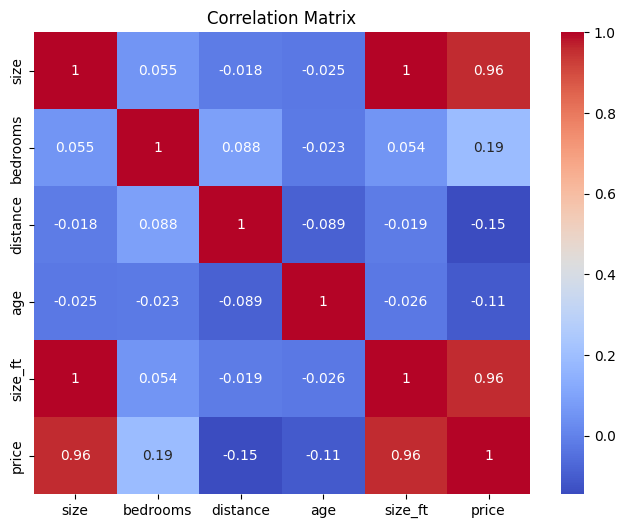

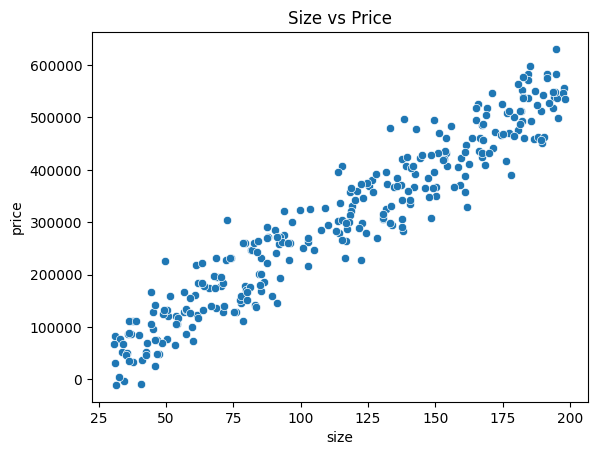

In [ ]:
dataset = create_dataset()
explore_data(dataset)


 Noise: 300

=== DATA INFO ===
         size  bedrooms   distance        age      size_ft          price
0   93.671820         5  11.812548  12.435138  1013.341452  275961.655244
1  191.621432         4   2.206725  25.905544  2060.586803  583421.007925
2  154.438970         3   1.699615  27.688807  1653.305272  407922.073315
3  131.771942         4   3.543190  13.971004  1428.128513  395196.464470
4   56.523169         5   1.259767  14.425109   606.055170  167494.904296

=== CORRELATION ===
              size  bedrooms  distance       age   size_ft     price
size      1.000000  0.054790 -0.017780 -0.025462  0.999810  0.957724
bedrooms  0.054790  1.000000  0.087856 -0.023096  0.054320  0.186084
distance -0.017780  0.087856  1.000000 -0.088974 -0.019169 -0.145007
age      -0.025462 -0.023096 -0.088974  1.000000 -0.026122 -0.107267
size_ft   0.999810  0.054320 -0.019169 -0.026122  1.000000  0.957595
price     0.957724  0.186084 -0.145007 -0.107267  0.957595  1.000000


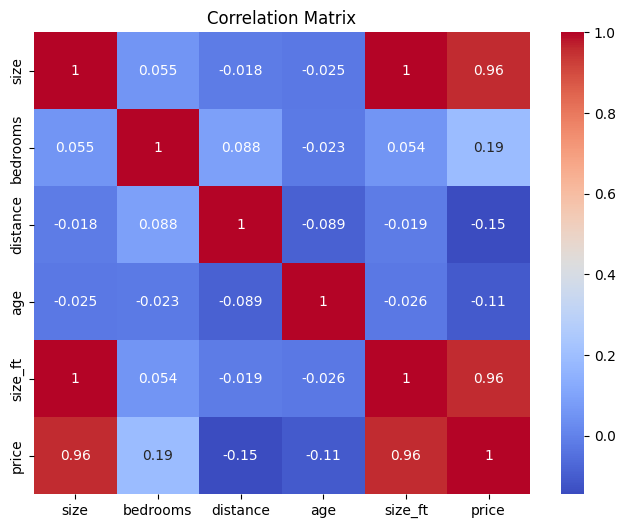

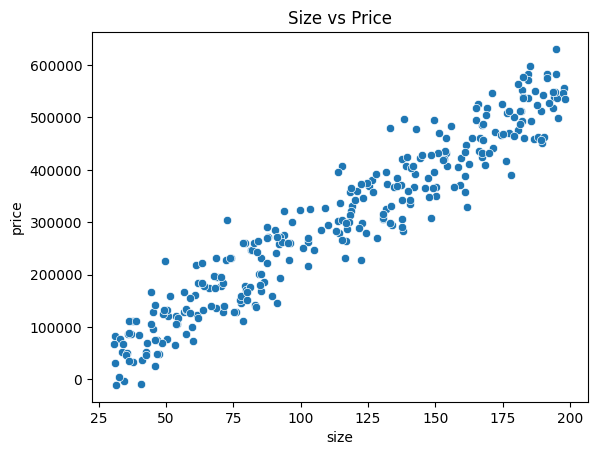


WITHOUT PCA

Linear Model:
RMSE  :29472.58
R2    :0.9594

Ridge Model:
RMSE  :29606.87
R2    :0.9590

Lasso Model:
RMSE  :29488.92
R2    :0.9594

=== PCA EXPLAINED VARIANCE ===
[0.40470317 0.22057382]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.058e+11, tolerance: 6.021e+08
  model = cd_fast.enet_coordinate_descent(


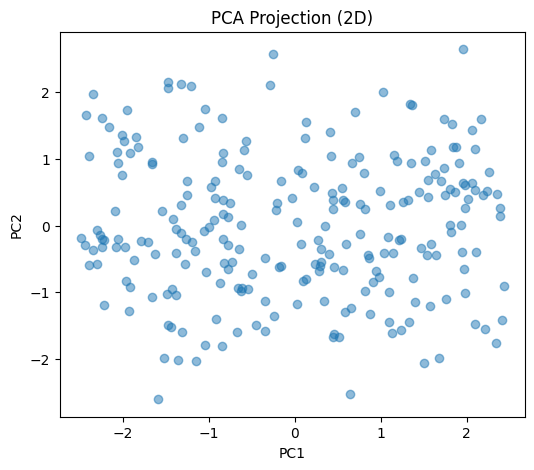


WITH PCA

Linear Model:
RMSE  :38592.69
R2    :0.9304

Ridge Model:
RMSE  :38579.38
R2    :0.9304

Lasso Model:
RMSE  :38592.69
R2    :0.9304


In [ ]:
# =========================================================
# 3. TRAIN MODEL
# =========================================================
def train_models(X_train, X_test, y_train, y_test):
  models = {
      "Linear": LinearRegression(),
      "Ridge": Ridge(alpha=1.0),
      "Lasso": Lasso(alpha=0.1)
  }

  results = {}

  for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = (rmse, r2)

    print(f"\n{name} Model:")
    print(f"RMSE  :{rmse:.2f}")
    print(f"R2    :{r2:.4f}")

  return results

# =========================================================
# 4. PCA + VISUALIZATION
# =========================================================
def apply_pca(X_scaled):
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X_scaled)

  print("\n=== PCA EXPLAINED VARIANCE ===")
  print(pca.explained_variance_ratio_)

  # Plot PCA
  plt.figure(figsize=(6, 5))
  plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
  plt.title("PCA Projection (2D)")
  plt.xlabel("PC1")
  plt.ylabel("PC2")
  plt.show()

  return X_pca

# =========================================================
# 5. MAIN PIPELINE
# =========================================================
def main():
  # 1. Load data
  df = create_dataset()

  # 2. Explore
  explore_data(df)

  # 3. Split
  X = df.drop("price", axis=1).values
  y = df["price"].values

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # 4. Scale
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # 5. Train without PCA
  print("\n==============================")
  print("WITHOUT PCA")
  print("==============================")
  train_models(X_train_scaled, X_test_scaled, y_train, y_test)

  # 6. PCA
  X_train_pca = apply_pca(X_train_scaled)
  X_test_pca = PCA(n_components=2).fit(X_train_scaled).transform(X_test_scaled)

  # 7. Train with PCA
  print("\n==============================")
  print("WITH PCA")
  print("==============================")
  train_models(X_train_pca, X_test_pca, y_train, y_test)

if __name__ == "__main__":
  main()